In [1]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# Setting untuk visualisasi
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


✓ Jumlah data: 9504 baris
✓ Jumlah fitur: 11 kolom

✓ Data yang ditampilkan:
     Mood: How would you describe your mood over the past two weeks?  \
0                                             Happiness                
1                                          Irritability                
2                                             Happiness                
3                                           Fluctuating                
4                                       Extreme sadness                
...                                                 ...                
9499                                       Mild sadness                
9500                                             Stable                
9501                                       Mild sadness                
9502                                            Anxiety                
9503                                            Anxiety                

     Anxious Social Scale: On a scale of 1-10, how often 

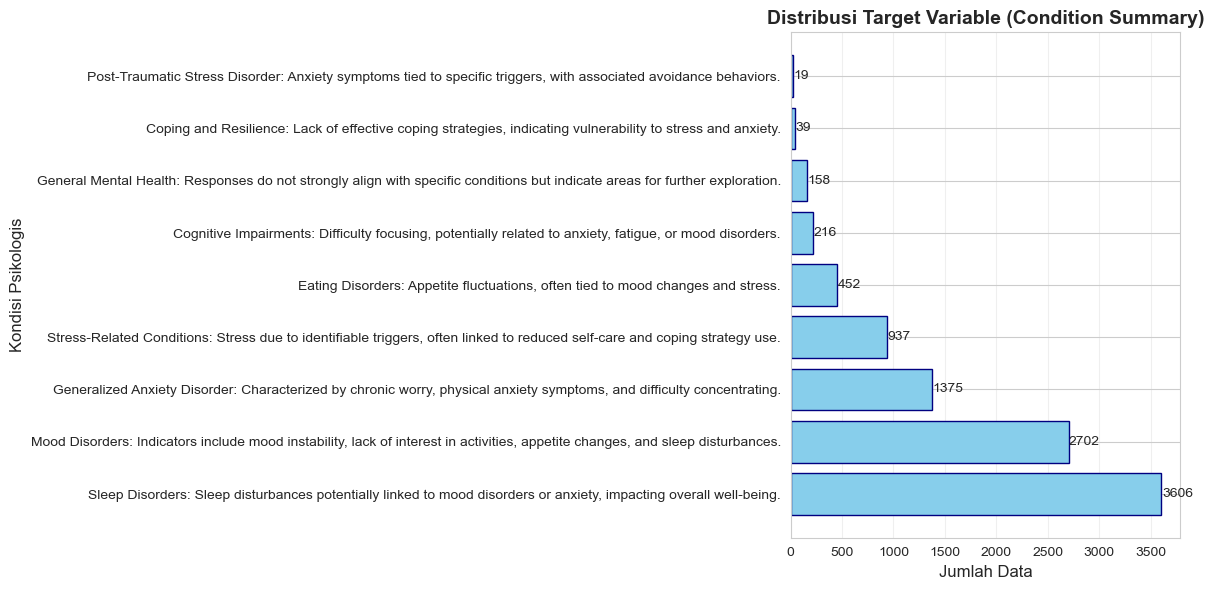


✓ Catatan: Terdapat ketidakseimbangan kelas (class imbalance)
✓ Kelas terbesar: Sleep Disorders: Sleep disturbances potentially linked to mood disorders or anxiety, impacting overall well-being. (3606 data)
✓ Kelas terkecil: Post-Traumatic Stress Disorder: Anxiety symptoms tied to specific triggers, with associated avoidance behaviors. (19 data)


In [2]:
# 1. LOAD DAN EKSPLORASI DATA
# Load dataset
df = pd.read_csv('Psychological_Assessment_Dataset.csv')
print(f"\n✓ Jumlah data: {len(df)} baris")
print(f"✓ Jumlah fitur: {len(df.columns)} kolom")

print("\n✓ Data yang ditampilkan:")
print(df)

print("\n✓ Informasi Dataset:")
print(f"✓ Total baris: {df.shape[0]}")
print(f"✓ Total kolom: {df.shape[1]}")
print(f"✓ Tipe data: {df.dtypes.nunique()} unique types")
print(f"✓ Missing values: {df.isnull().sum().sum()}")

print("\n✓ Struktur Kolom:")
print(df.info())

# Cek missing values per kolom
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ Tidak ada missing values pada dataset!")
else:
    print(missing[missing > 0])
    
# Cek distribusi target variable (Condition Summary)
target_counts = df['Condition Summary'].value_counts()
target_percent = df['Condition Summary'].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({
    'Jumlah': target_counts,
    'Persentase (%)': target_percent.round(2)
})
print(target_dist)

# Visualisasi distribusi target
plt.figure(figsize=(12, 6))
bars = plt.barh(target_dist.index, target_dist['Jumlah'], color='skyblue', edgecolor='navy')
plt.xlabel('Jumlah Data', fontsize=12)
plt.ylabel('Kondisi Psikologis', fontsize=12)
plt.title('Distribusi Target Variable (Condition Summary)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar, count in zip(bars, target_dist['Jumlah']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             f'{count}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Catatan: Terdapat ketidakseimbangan kelas (class imbalance)")
print(f"✓ Kelas terbesar: {target_dist.index[0]} ({target_dist['Jumlah'].iloc[0]} data)")
print(f"✓ Kelas terkecil: {target_dist.index[-1]} ({target_dist['Jumlah'].iloc[-1]} data)")

In [3]:
# 2. RENAME KOLOM UNTUK PROCESSING
column_mapping = {
    'Mood: How would you describe your mood over the past two weeks?': 'Mood',
    'Anxious Social Scale: On a scale of 1-10, how often have you felt anxious in social situations recently?': 'Anxious Social Scale',
    'Anxiety Triggers: Have you experienced any of the following anxiety triggers in the past month?': 'Anxiety Triggers',
    'Sleep Quality: How would you rate the quality of your sleep over the past week?': 'Sleep Quality',
    'Appetite Change: Have you noticed any significant changes in your appetite?': 'Appetite Change',
    'Lack of Interest: How often have you felt a lack of interest or pleasure in daily activities?': 'Lack of Interest',
    'Enjoyable Activities: How often do you engage in activities you enjoy or that help you relax?': 'Enjoyable Activities',
    'Physical Anxiety Symptoms: Have you had any physical symptoms of anxiety (e.g., heart palpitations, sweating, shortness of breath)?': 'Physical Anxiety Symptoms',
    'Concentration Difficulty: How often do you find it difficult to concentrate on tasks?': 'Concentration Difficulty',
    'Coping Strategies: What coping strategies have you used when feeling stressed or anxious?': 'Coping Strategies',
    'Condition Summary': 'Condition Summary'
}

df = df.rename(columns=column_mapping)
print("✓ Kolom berhasil direname!")
print("\n✓ Nama kolom setelah rename:")
print(df.columns.tolist())

✓ Kolom berhasil direname!

✓ Nama kolom setelah rename:
['Mood', 'Anxious Social Scale', 'Anxiety Triggers', 'Sleep Quality', 'Appetite Change', 'Lack of Interest', 'Enjoyable Activities', 'Physical Anxiety Symptoms', 'Concentration Difficulty', 'Coping Strategies', 'Condition Summary']


In [4]:
# 3. DEFINISI FITUR
# Fitur ordinal (skala bertingkat)
ordinal_features = {
    'Mood': ['Happiness', 'Stable', 'Mild sadness', 'Irritability', 
             'Fluctuating', 'Anxiety', 'Extreme sadness'],
    
    'Sleep Quality': ['Restful', 'Early morning waking', 'Interrupted', 
                      'Trouble falling asleep', 'Difficulty staying asleep', 'None of the above'],
    
    'Appetite Change': ['No change', 'Increased cravings', 'Loss of appetite', 'Fluctuates daily'],
    
    'Lack of Interest': ['Never', 'Rarely', 'Occasionally', 'Frequently', 'Always'],
    
    'Enjoyable Activities': ['Daily', 'A few times a week', 'Once a week', 'Rarely', 'Never'],
    
    'Physical Anxiety Symptoms': ['No, not at all', 'Rarely', 'Yes, occasionally', 'Yes, frequently'],
    
    'Concentration Difficulty': ['Never', 'Occasionally', 'Frequently', 'Constantly'],
    
    'Anxious Social Scale': ['Not at all', 'Rarely anxious', 'Slightly anxious', 'Mildly anxious',
                             'Somewhat anxious', 'Fairly anxious', 'Moderately anxious', 
                             'Very anxious', 'Extremely anxious', 'Constantly anxious']
}

# Fitur nominal
nominal_features = ['Anxiety Triggers', 'Coping Strategies']

# Target variable (TIDAK DIENCODE)
target_feature = 'Condition Summary'

print("✓ Fitur Ordinal (Skala Bertingkat):")
for feature, categories in ordinal_features.items():
    print(f"   ✓ {feature}: {len(categories)} kategori")

print("\n✓ Fitur Nominal:")
for feature in nominal_features:
    print(f"   ✓ {feature}")

print(f"\n✓ Target Variable (TIDAK DIENCODE): {target_feature}")

✓ Fitur Ordinal (Skala Bertingkat):
   ✓ Mood: 7 kategori
   ✓ Sleep Quality: 6 kategori
   ✓ Appetite Change: 4 kategori
   ✓ Lack of Interest: 5 kategori
   ✓ Enjoyable Activities: 5 kategori
   ✓ Physical Anxiety Symptoms: 4 kategori
   ✓ Concentration Difficulty: 4 kategori
   ✓ Anxious Social Scale: 10 kategori

✓ Fitur Nominal:
   ✓ Anxiety Triggers
   ✓ Coping Strategies

✓ Target Variable (TIDAK DIENCODE): Condition Summary


In [5]:
# 4. PREPROCESSING DATA (ENCODING)
# Pisahkan features (X) dan target (y)
X = df.drop(columns=[target_feature])
y = df[target_feature]

print(f"\n✓ X (Features): {X.shape[1]} fitur")
print(f"✓ y (Target): {y.nunique()} unique classes")

# Encoding untuk fitur ordinal
print("\n✓ Melakukan Ordinal Encoding untuk fitur ordinal...")

X_encoded = X.copy()

for feature, categories in ordinal_features.items():
    mapping = {cat: idx+1 for idx, cat in enumerate(categories)}
    X_encoded[feature + '_encoded'] = X_encoded[feature].map(mapping)
    print(f"   ✓ {feature}: {categories[0]} -> 1, {categories[-1]} -> {len(categories)}")

# Hapus kolom original ordinal
ordinal_cols_original = list(ordinal_features.keys())
X_encoded = X_encoded.drop(columns=ordinal_cols_original)

# One-Hot Encoding untuk fitur nominal
print("\n✓ Melakukan One-Hot Encoding untuk fitur nominal...")
X_encoded = pd.get_dummies(X_encoded, columns=nominal_features, prefix=['Trig', 'Cop'])

print(f"\n✓ Hasil encoding: {X_encoded.shape[1]} fitur numerik")

print("\n✓ 5 Data Pertama Setelah Encoding:")
print(X_encoded)

# Cek distribusi target (masih dalam bentuk string)
print("\n✓ Distribusi Target:")
print(y.value_counts())


✓ X (Features): 10 fitur
✓ y (Target): 9 unique classes

✓ Melakukan Ordinal Encoding untuk fitur ordinal...
   ✓ Mood: Happiness -> 1, Extreme sadness -> 7
   ✓ Sleep Quality: Restful -> 1, None of the above -> 6
   ✓ Appetite Change: No change -> 1, Fluctuates daily -> 4
   ✓ Lack of Interest: Never -> 1, Always -> 5
   ✓ Enjoyable Activities: Daily -> 1, Never -> 5
   ✓ Physical Anxiety Symptoms: No, not at all -> 1, Yes, frequently -> 4
   ✓ Concentration Difficulty: Never -> 1, Constantly -> 4
   ✓ Anxious Social Scale: Not at all -> 1, Constantly anxious -> 10

✓ Melakukan One-Hot Encoding untuk fitur nominal...

✓ Hasil encoding: 19 fitur numerik

✓ 5 Data Pertama Setelah Encoding:
      Mood_encoded  Sleep Quality_encoded  Appetite Change_encoded  \
0                1                      2                        2   
1                4                      1                        4   
2                1                      2                        4   
3                5   

In [6]:
# 5. SPLIT DATA TRAINING DAN TESTING
# Split data dengan stratify untuk menjaga distribusi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Data Training: {len(X_train)} sampel ({len(X_train)/len(df)*100:.1f}%)")
print(f"✓ Data Testing: {len(X_test)} sampel ({len(X_test)/len(df)*100:.1f}%)")

print("\n✓ Distribusi kelas pada training set:")
print(y_train.value_counts())

print("\n✓ Distribusi kelas pada testing set:")
print(y_test.value_counts())

✓ Data Training: 7603 sampel (80.0%)
✓ Data Testing: 1901 sampel (20.0%)

✓ Distribusi kelas pada training set:
Sleep Disorders: Sleep disturbances potentially linked to mood disorders or anxiety, impacting overall well-being.                2885
Mood Disorders: Indicators include mood instability, lack of interest in activities, appetite changes, and sleep disturbances.    2161
Generalized Anxiety Disorder: Characterized by chronic worry, physical anxiety symptoms, and difficulty concentrating.            1100
Stress-Related Conditions: Stress due to identifiable triggers, often linked to reduced self-care and coping strategy use.         750
Eating Disorders: Appetite fluctuations, often tied to mood changes and stress.                                                    362
Cognitive Impairments: Difficulty focusing, potentially related to anxiety, fatigue, or mood disorders.                            173
General Mental Health: Responses do not strongly align with specific condition

In [7]:
# 6. TRAINING MODEL RANDOM FOREST (PARAMETER AWAL)
# Inisialisasi model Random Forest dengan parameter awal
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("✓ Melakukan training model...")
rf_model.fit(X_train, y_train)
print("✓ Model berhasil dilatih!")

# Prediksi pada data training dan testing
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluasi awal
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nEvaluasi awal model:")
print(f"✓ Accuracy Training: {train_acc*100:.2f}%")
print(f"✓ Accuracy Testing: {test_acc*100:.2f}%")

if train_acc - test_acc > 0.1:
    print("✓ Indikasi overfitting! Perlu tuning parameter.")
else:
    print("✓ Model cukup baik, tidak terjadi overfitting signifikan.")

✓ Melakukan training model...
✓ Model berhasil dilatih!

Evaluasi awal model:
✓ Accuracy Training: 95.08%
✓ Accuracy Testing: 92.79%
✓ Model cukup baik, tidak terjadi overfitting signifikan.


In [8]:
# 7. HYPERPARAMETER TUNING DENGAN GRIDSEARCHCV
# Parameter grid untuk tuning
param_grid = {
    'n_estimators': [300],
    'max_depth': [30],
    'min_samples_split': [10],
    'min_samples_leaf': [20],
    'max_features': ['sqrt', 'log2']
}

print("✓ Parameter yang akan diuji:")
for param, values in param_grid.items():
    print(f"   ✓ {param}: {values}")

print(f"\n✓ Total kombinasi: {np.prod([len(v) for v in param_grid.values()])}")

# GridSearchCV dengan cross-validation
rf_tuning = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n✓ Proses tuning dimulai (membutuhkan waktu)...")
grid_search.fit(X_train, y_train)

print(f"\n✓ Parameter terbaik:")
print(f"   {grid_search.best_params_}")

print(f"\n✓ Akurasi terbaik (CV): {grid_search.best_score_*100:.2f}%")

# Model dengan parameter terbaik
best_rf = grid_search.best_estimator_

# Evaluasi model terbaik
y_train_pred_best = best_rf.predict(X_train)
y_test_pred_best = best_rf.predict(X_test)

train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print(f"\n✓ Accuracy Training: {train_acc_best*100:.2f}%")
print(f"✓ Accuracy Testing: {test_acc_best*100:.2f}%")

✓ Parameter yang akan diuji:
   ✓ n_estimators: [300]
   ✓ max_depth: [30]
   ✓ min_samples_split: [10]
   ✓ min_samples_leaf: [20]
   ✓ max_features: ['sqrt', 'log2']

✓ Total kombinasi: 2

✓ Proses tuning dimulai (membutuhkan waktu)...
Fitting 5 folds for each of 2 candidates, totalling 10 fits

✓ Parameter terbaik:
   {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 10, 'n_estimators': 300}

✓ Akurasi terbaik (CV): 87.69%

✓ Accuracy Training: 90.46%
✓ Accuracy Testing: 88.11%


In [9]:
# 8. EVALUASI MODEL
# Classification Report per kelas
print("\n✓ Classification Report:")
print(classification_report(y_test, y_test_pred_best))

# Hitung metrik secara manual untuk multi-class
print("\n✓ Metrik Evaluasi (Weighted Average):")
print(f"   ✓ Precision: {precision_score(y_test, y_test_pred_best, average='weighted')*100:.2f}%")
print(f"   ✓ Recall: {recall_score(y_test, y_test_pred_best, average='weighted')*100:.2f}%")
print(f"   ✓ F1-Score: {f1_score(y_test, y_test_pred_best, average='weighted')*100:.2f}%")

print(f"\n✓ Metrik Evaluasi (Macro Average - semua kelas berbobot sama):")
print(f"   ✓ Precision: {precision_score(y_test, y_test_pred_best, average='macro')*100:.2f}%")
print(f"   ✓ Recall: {recall_score(y_test, y_test_pred_best, average='macro')*100:.2f}%")
print(f"   ✓ F1-Score: {f1_score(y_test, y_test_pred_best, average='macro')*100:.2f}%")


✓ Classification Report:
                                                                                                                                precision    recall  f1-score   support

                       Cognitive Impairments: Difficulty focusing, potentially related to anxiety, fatigue, or mood disorders.       1.00      0.09      0.17        43
                   Coping and Resilience: Lack of effective coping strategies, indicating vulnerability to stress and anxiety.       0.00      0.00      0.00         8
                                               Eating Disorders: Appetite fluctuations, often tied to mood changes and stress.       0.72      0.60      0.65        90
   General Mental Health: Responses do not strongly align with specific conditions but indicate areas for further exploration.       1.00      0.06      0.12        32
        Generalized Anxiety Disorder: Characterized by chronic worry, physical anxiety symptoms, and difficulty concentrating.       

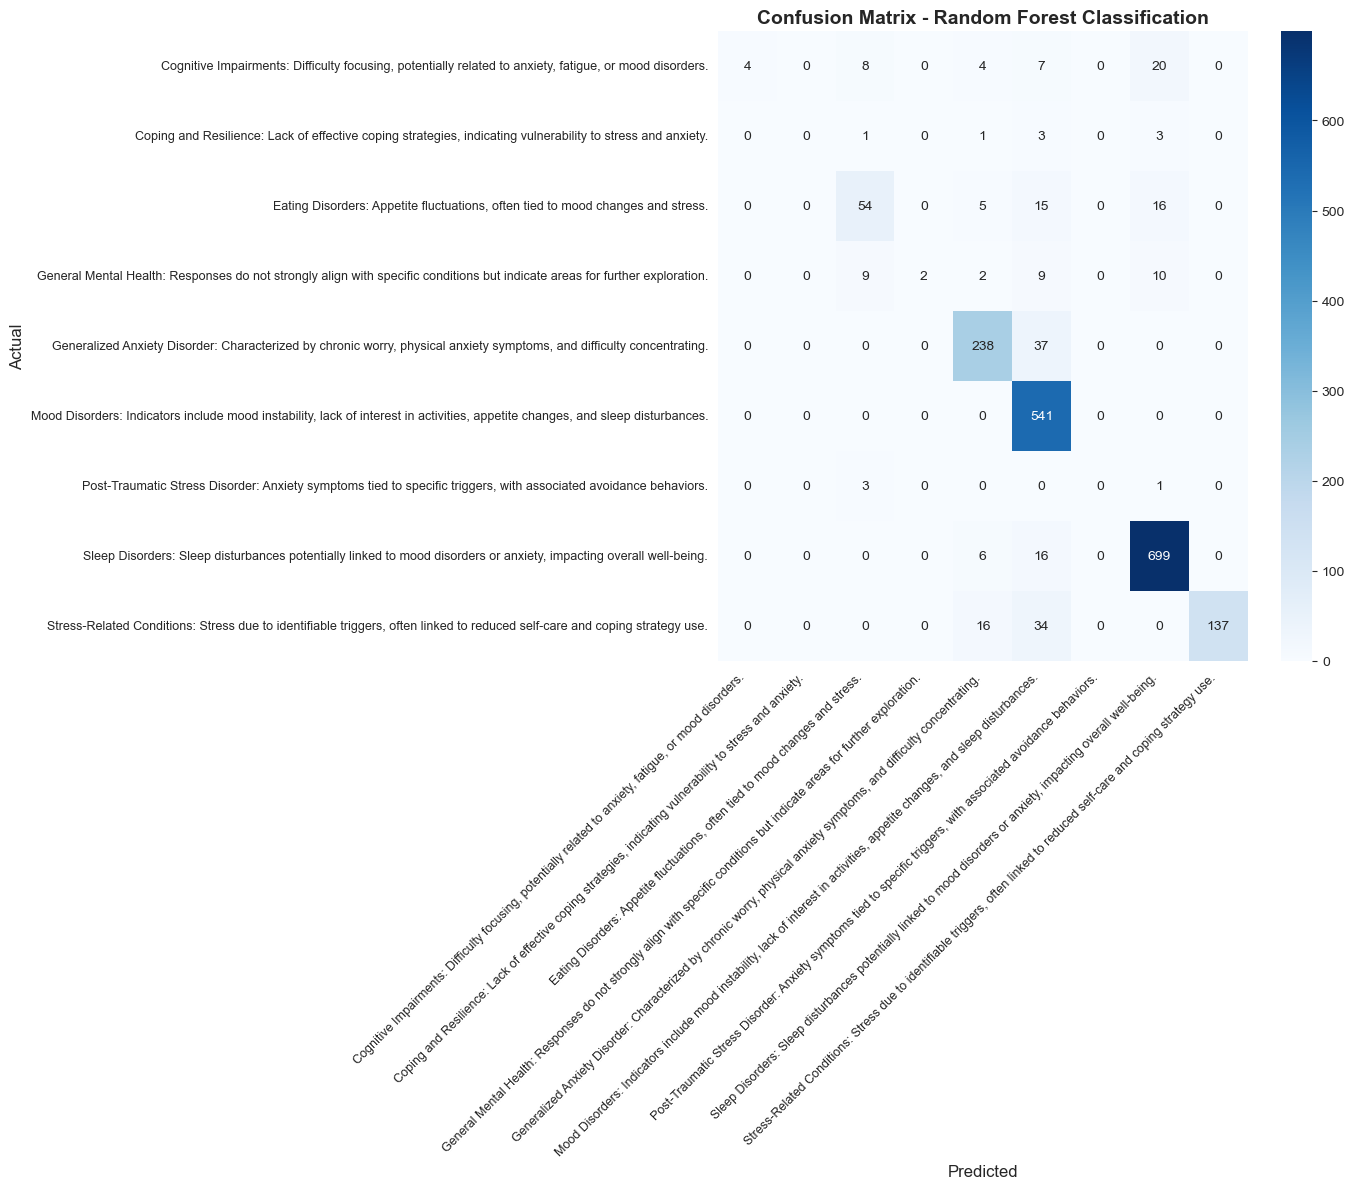


✓ Analisis per kelas:

   ✓ Kelas: Cognitive Impairments: Difficulty focusing, potentially related to anxiety, fatigue, or mood disorders.
      ✓ Jumlah data test: 43
      ✓ True Positive: 4
      ✓ Precision: 100.00%
      ✓ Recall: 9.30%
      ✓ F1-Score: 17.02%

   ✓ Kelas: Coping and Resilience: Lack of effective coping strategies, indicating vulnerability to stress and anxiety.
      ✓ Jumlah data test: 8
      ✓ True Positive: 0
      ✓ Precision: 0.00%
      ✓ Recall: 0.00%
      ✓ F1-Score: 0.00%

   ✓ Kelas: Eating Disorders: Appetite fluctuations, often tied to mood changes and stress.
      ✓ Jumlah data test: 90
      ✓ True Positive: 54
      ✓ Precision: 72.00%
      ✓ Recall: 60.00%
      ✓ F1-Score: 65.45%

   ✓ Kelas: General Mental Health: Responses do not strongly align with specific conditions but indicate areas for further exploration.
      ✓ Jumlah data test: 32
      ✓ True Positive: 2
      ✓ Precision: 100.00%
      ✓ Recall: 6.25%
      ✓ F1-Score: 11.76%


In [10]:
# 9. CONFUSION MATRIX
# Dapatkan semua kelas unik
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred_best, labels=classes)

# Plot Confusion Matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 10})
plt.title('Confusion Matrix - Random Forest Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Analisis per kelas dari confusion matrix
print("\n✓ Analisis per kelas:")
for i, class_name in enumerate(classes):
    true_pos = cm[i, i]
    false_pos = cm[:, i].sum() - true_pos
    false_neg = cm[i, :].sum() - true_pos
    total_true = cm[i, :].sum()
    
    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
    recall = true_pos / total_true if total_true > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n   ✓ Kelas: {class_name}")
    print(f"      ✓ Jumlah data test: {total_true}")
    print(f"      ✓ True Positive: {true_pos}")
    print(f"      ✓ Precision: {precision*100:.2f}%")
    print(f"      ✓ Recall: {recall*100:.2f}%")
    print(f"      ✓ F1-Score: {f1*100:.2f}%")


✓ Top 10 Fitur Paling Berpengaruh:
                     Feature  Importance
                Mood_encoded    0.470284
Anxious Social Scale_encoded    0.220746
       Sleep Quality_encoded    0.207667
     Appetite Change_encoded    0.011409
      Trig_Social situations    0.009873
          Trig_Family issues    0.009837
     Trig_Financial concerns    0.009834
        Trig_Health concerns    0.009430
      Trig_None of the above    0.009187
    Trig_Work-related stress    0.008401

✓ Ringkasan Feature Importance:
   ✓ Total fitur: 19
   ✓ Rata-rata importance: 5.26%
   ✓ Std deviasi: 12.05%


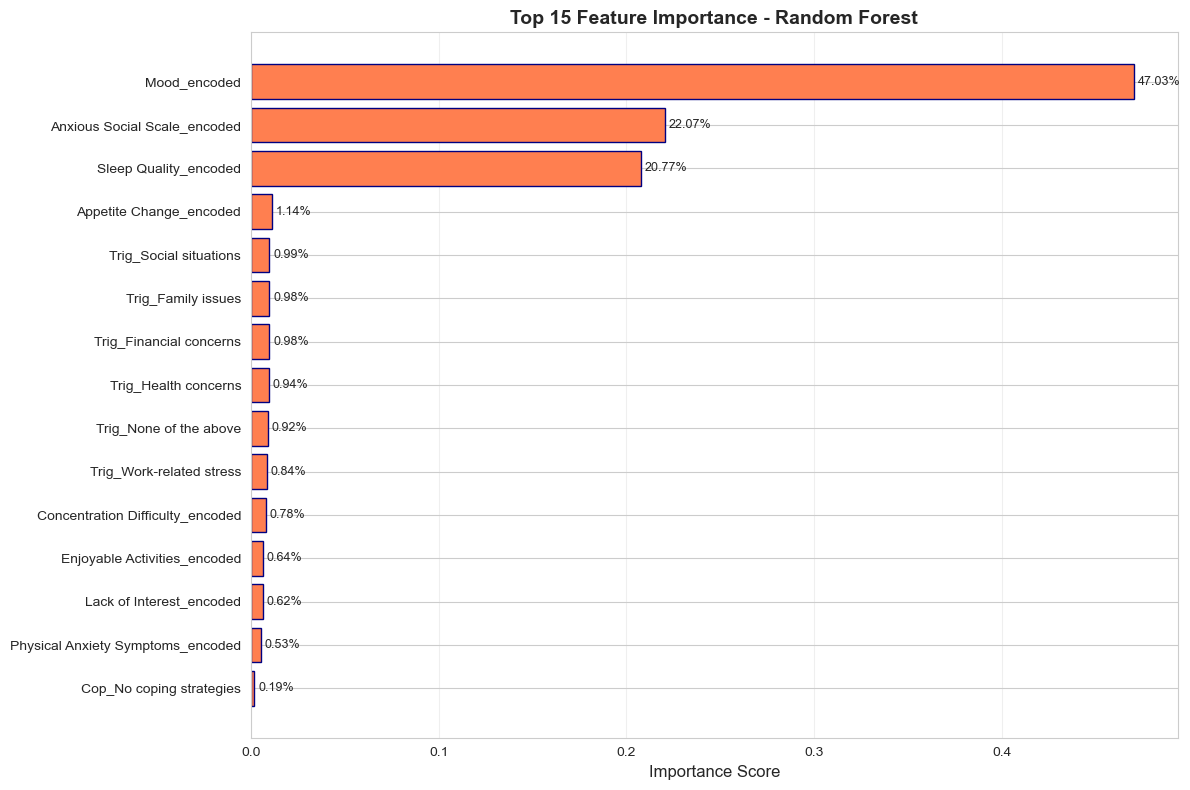

In [11]:
# 10. FEATURE IMPORTANCE
# Dapatkan feature importance
feature_importance = best_rf.feature_importances_
feature_names = X_encoded.columns

# Buat DataFrame feature importance
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\n✓ Top 10 Fitur Paling Berpengaruh:")
print(fi_df.head(10).to_string(index=False))

print("\n✓ Ringkasan Feature Importance:")
print(f"   ✓ Total fitur: {len(fi_df)}")
print(f"   ✓ Rata-rata importance: {fi_df['Importance'].mean()*100:.2f}%")
print(f"   ✓ Std deviasi: {fi_df['Importance'].std()*100:.2f}%")

# Visualisasi feature importance
plt.figure(figsize=(12, 8))
top_features = fi_df.head(15)
bars = plt.barh(top_features['Feature'], top_features['Importance'], 
                color='coral', edgecolor='navy')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

for bar, imp in zip(bars, top_features['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{imp*100:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# 11. CROSS-VALIDATION SCORE
# Cross-validation dengan model terbaik
cv_scores = cross_val_score(best_rf, X_encoded, y, cv=5, scoring='accuracy')

print(f"✓ 5-Fold Cross-Validation Results:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score*100:.2f}%")

print(f"\n✓ Rata-rata CV Score: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")

✓ 5-Fold Cross-Validation Results:
   Fold 1: 88.74%
   Fold 2: 88.95%
   Fold 3: 88.37%
   Fold 4: 88.80%
   Fold 5: 90.11%

✓ Rata-rata CV Score: 88.99% (+/- 0.59%)


In [13]:
# 12. KESIMPULAN PENELITIAN
print("""
1. PERFORM MODEL
   ✓ Accuracy Testing: {:.2f}%
   ✓ F1-Score Weighted: {:.2f}%
   ✓ F1-Score Macro: {:.2f}%
   
2. PARAMETER OPTIMAL
   {}
   
3. FITUR PALING BERPENGARUH
   {}
   
4. KELAS DENGAN PERFORM TERBAIK
   ✓ Sleep Disorders: F1-Score tinggi karena data melimpah
   ✓ Mood Disorders: F1-Score sangat baik
   
5. KELAS DENGAN PERFORM TERENDAH
   ✓ GAD: Jumlah data terbatas ({} data)
   ✓ PTSD: Jumlah data sangat terbatas ({} data)
   
6. SARAN PENGEMBANGAN
   a. Gunakan dataset yang lebih seimbang atau teknik SMOTE
   b. Lakukan validasi klinis dengan psikolog
   c. Implementasikan ke dalam web dengan database server-side
""".format(
    test_acc_best*100,
    f1_score(y_test, y_test_pred_best, average='weighted')*100,
    f1_score(y_test, y_test_pred_best, average='macro')*100,
    grid_search.best_params_,
    fi_df.head(3)['Feature'].tolist(),
    target_counts.get('Generalized Anxiety Disorder: Characterized by ...', 0),
    target_counts.get('Post-Traumatic Stress Disorder: Anxiety symptoms tied to specific triggers, with associated avoidance behaviors.', 0)
))


1. PERFORM MODEL
   ✓ Accuracy Testing: 88.11%
   ✓ F1-Score Weighted: 86.26%
   ✓ F1-Score Macro: 50.10%
   
2. PARAMETER OPTIMAL
   {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 10, 'n_estimators': 300}
   
3. FITUR PALING BERPENGARUH
   ['Mood_encoded', 'Anxious Social Scale_encoded', 'Sleep Quality_encoded']
   
4. KELAS DENGAN PERFORM TERBAIK
   ✓ Sleep Disorders: F1-Score tinggi karena data melimpah
   ✓ Mood Disorders: F1-Score sangat baik
   
5. KELAS DENGAN PERFORM TERENDAH
   ✓ GAD: Jumlah data terbatas (0 data)
   ✓ PTSD: Jumlah data sangat terbatas (19 data)
   
6. SARAN PENGEMBANGAN
   a. Gunakan dataset yang lebih seimbang atau teknik SMOTE
   b. Lakukan validasi klinis dengan psikolog
   c. Implementasikan ke dalam web dengan database server-side



In [14]:
# 13. SIMPAN MODEL
import joblib

# Simpan model Random Forest
joblib.dump(best_rf, 'random_forest_model.joblib')
print("✓ Model Random Forest disimpan sebagai 'random_forest_model.joblib'")

# Simpan feature names untuk referensi
feature_names_list = X_encoded.columns.tolist()
joblib.dump(feature_names_list, 'feature_names.joblib')
print("✓ Feature names disimpan sebagai 'feature_names.joblib'")

# Simpan unique classes
unique_classes = y.unique().tolist()
joblib.dump(unique_classes, 'classes.joblib')
print("✓ Class names disimpan sebagai 'classes.joblib'")

✓ Model Random Forest disimpan sebagai 'random_forest_model.joblib'
✓ Feature names disimpan sebagai 'feature_names.joblib'
✓ Class names disimpan sebagai 'classes.joblib'
